In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
df=pd.read_csv("CIRC_model_ready.csv")
print(df.shape)
df.isnull().sum()
df.head()

(1141, 14)


,D,t,Fy,fc,L,Dt,LD,Ac,As,SteelCap,ConcCap,Squash,Xi,Pexp
0,94.996,12.4968,274.618291,27.365302,1420.114,7.601626,14.949198,3848.714899,3238.906636,889.463004,105.321247,994.784252,8.445238,947.026382
1,94.996,12.7508,272.618810,27.365302,1420.114,7.450199,14.949198,3793.058149,3294.563385,898.159951,103.798183,1001.958134,8.652945,937.685116
2,94.996,12.3952,272.618810,27.365302,1420.114,7.663934,14.949198,3871.091101,3216.530433,876.886700,105.933579,982.820279,8.277703,906.992387
3,94.996,12.5984,274.618291,27.365302,860.044,7.540323,9.053476,3826.403555,3261.217979,895.590107,104.710691,1000.300798,8.552996,1017.753106
4,94.996,12.7000,272.618810,27.365302,860.044,7.480000,9.053476,3804.157070,3283.464465,895.134176,104.101909,999.236085,8.598634,1007.967018


### Transforming Data

In [3]:
x=df.drop("Pexp",axis=1)
y=df["Pexp"]

## Creating an ANN Model

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [5]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

# Standardization of data
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


# creating Tensor array
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

print(type(y_train))
print(type(x_train_scaled))
print(type(x_train_tensor))


# Creating Tensor dataset
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

# Creating dataset loader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

<class 'pandas.Series'>
<class 'numpy.ndarray'>
<class 'torch.Tensor'>


In [6]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            # 1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)
    

model=ANN()

# loss, optimizer
criterion=nn.MSELoss()
optimizer= optim.Adam(model.parameters())




In [7]:
# Training the ANN model

train_losses=[]
val_losses=[]
best_val_loss=float("inf")

epochs=100

for epoch in range(epochs):

    model.train()
    running_loss=0.0    # total training loss for 1 epoch

    for xb,yb in train_loader:      # xb & yb are features and lebels of 1 batch
        optimizer.zero_grad() 

        outputs=model(xb)       # forward prop. -> predict the output for this batch
        loss=criterion(outputs,yb)      # compute loss
        loss.backward()     # back prop. -> compute the gradients
        optimizer.step()    # params update

        running_loss+=loss.item()   # .item is used to convert the tensor value to float value as loss is tensor value
    
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():   # torch auto update gradients so we need to tell that we don't want to compute the gradient
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")      # for storing the model we use .pt ot .pth file extention


epoch 1/100 ==> train loss = 33234645.189655174 & val loss = 19449536.0
epoch 2/100 ==> train loss = 34837467.14655172 & val loss = 19449158.0
epoch 3/100 ==> train loss = 34773781.862068966 & val loss = 19448590.0
epoch 4/100 ==> train loss = 34645069.18965517 & val loss = 19447666.0
epoch 5/100 ==> train loss = 33123292.20689655 & val loss = 19446016.0
epoch 6/100 ==> train loss = 34929106.327586204 & val loss = 19443246.0
epoch 7/100 ==> train loss = 33282813.879310343 & val loss = 19438374.0
epoch 8/100 ==> train loss = 33075512.422413792 & val loss = 19430492.0
epoch 9/100 ==> train loss = 33327127.103448275 & val loss = 19418790.0
epoch 10/100 ==> train loss = 33152960.23275862 & val loss = 19402892.0
epoch 11/100 ==> train loss = 33029819.55172414 & val loss = 19379952.0
epoch 12/100 ==> train loss = 37240650.74137931 & val loss = 19352928.0
epoch 13/100 ==> train loss = 35678430.25862069 & val loss = 19323142.0
epoch 14/100 ==> train loss = 33554011.974137932 & val loss = 19284

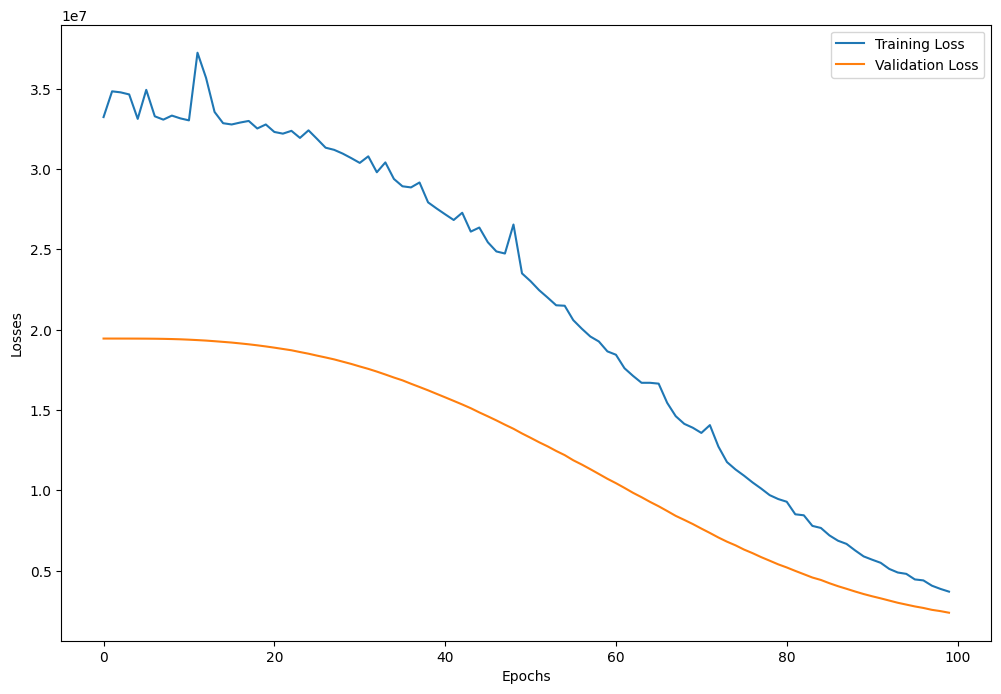

In [8]:
# Plot of losses
import matplotlib.pyplot as plt 

loss_df=pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [9]:
# Saving and loading the best model
model.load_state_dict(torch.load("best_model.pt"))


# Evaluation of the Model
model.eval()
with torch.no_grad():
    train_preds=model(x_train_tensor)
    test_preds=model(x_test_tensor)

    train_mse_loss=criterion(y_train_tensor,train_preds)
    test_mse_loss=criterion(y_test_tensor,test_preds)

print(f"Training MSE: {train_mse_loss}")
print(f"Testing MSE: {test_mse_loss}")

# r2_score
from sklearn.metrics import r2_score
print(f"R2 score for training: {r2_score(y_train,train_preds)}")
print(f"R2 score for testing: {r2_score(y_test,test_preds)}")


# Comparison of data 
predicted_df=pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df], axis=1)

Training MSE: 3651726.5
Testing MSE: 2639802.25
R2 score for training: 0.8627817836456092
R2 score for testing: 0.8374602406618898


,Predicted Values,Actual Values
0,2663.113770,2340.000000
1,771.035034,686.210000
2,1044.429077,575.650355
3,1642.730103,550.000000
4,2326.734863,4040.339800
...,...,...
224,661.920898,328.718908
225,1198.049194,2112.905267
226,45.815834,353.000000
227,689.512085,644.296905


Using device: mps

Original data split:
Training: (912, 13)
Testing : (229, 13)

ANN data split:
Training   : (775, 13)
Validation : (137, 13)
Final Test : (229, 13)

ANN Architecture:
ANN(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): SiLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): SiLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Training ANN...

Epoch    1/5000 | Train Loss = 0.482286 | Val Loss = 0.041327 | LR = 1.00e-03
Epoch  100/5000 | Train Loss = 0.022166 | Val Loss = 0.015377 | LR = 1.00e-03
Epoch  200/5000 | Train Loss = 0.007727 | Val Loss = 0.014040 | LR = 5.00e-04
Epoch  300/5000 | Train Loss = 0.004537 | Val Loss = 0.020256 | LR = 2.50e-04
Epoch  400/5000 | Train Loss = 0.003789 | Val Loss = 0.022237 | LR = 1.25e-04

Early

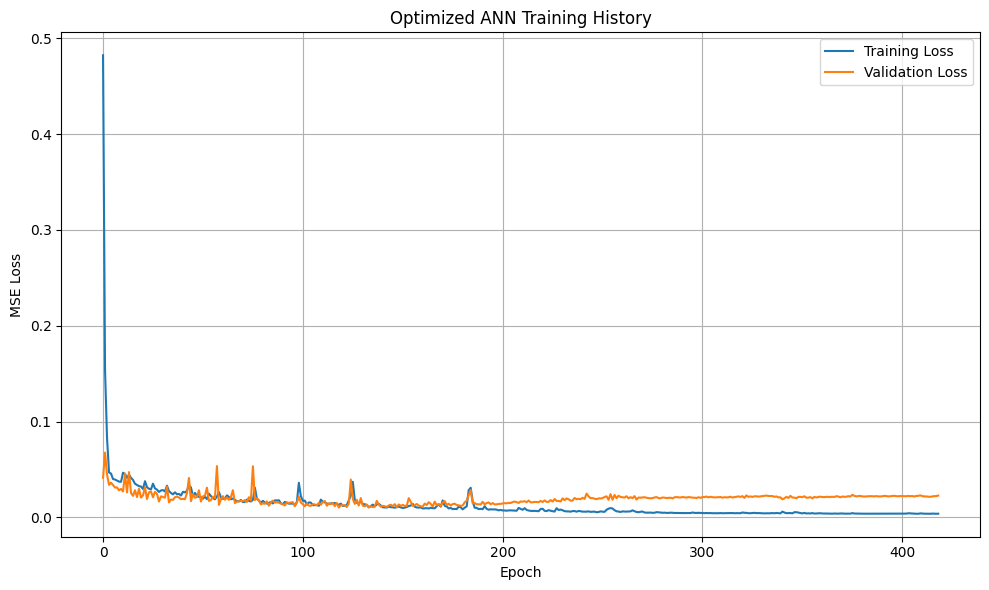

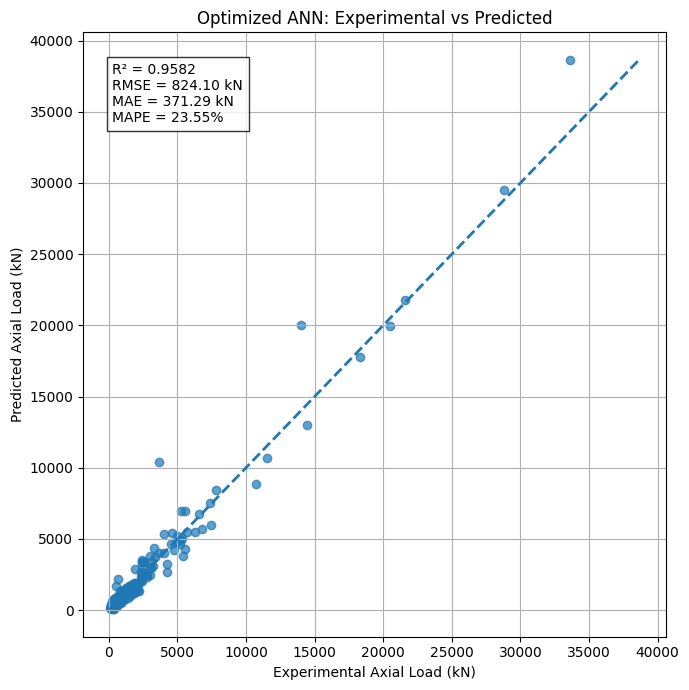

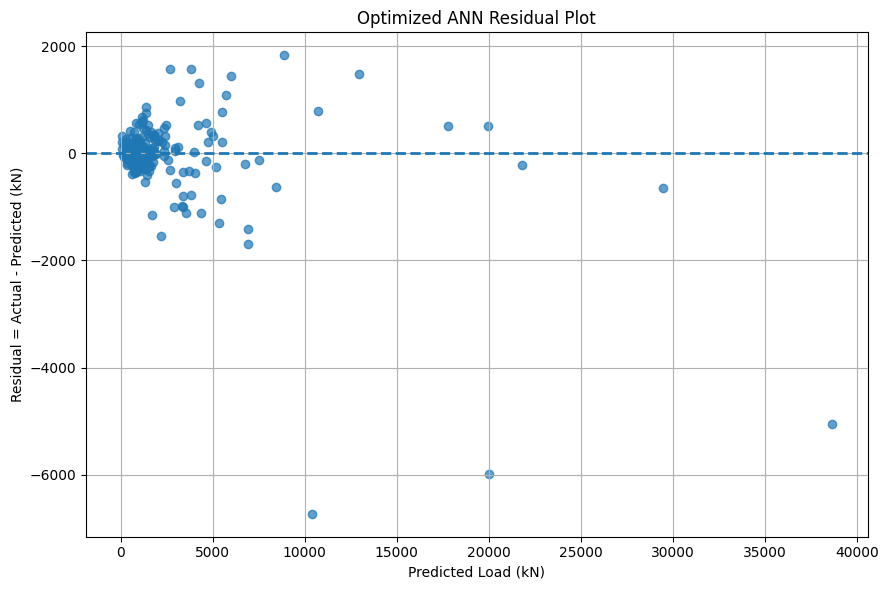


Actual vs Predicted:
    Actual Values  Predicted Values  Residual
0        2340.000       2381.409912   -41.410
1         686.210        908.622986  -222.413
2         575.650        598.271973   -22.621
3         550.000       1695.360962 -1145.361
4        4040.340       5333.189941 -1292.850
5        1325.570       1413.103027   -87.533
6        1314.091       1543.109985  -229.019
7        7432.978       5984.532227  1448.447
8        1067.000       1058.213013     8.787
9        1372.931       1306.427979    66.503
10       4519.000       4654.961914  -135.962
11       1112.055       1284.844971  -172.790
12        540.950        618.179016   -77.229
13       5714.000       5508.308105   205.692
14       6538.000       6743.778809  -205.779
15       1167.300       1149.709961    17.590
16       2386.000       3361.266113  -975.267
17       1085.000       1172.505981   -87.506
18        244.000        351.834015  -107.834
19        825.720        726.502991    99.217

Model saved

In [10]:
import random
import copy
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("\nOriginal data split:")
print("Training:", x_train.shape)
print("Testing :", x_test.shape)
x_ann_train, x_val, y_ann_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=42
)
print("\nANN data split:")
print("Training   :", x_ann_train.shape)
print("Validation :", x_val.shape)
print("Final Test :", x_test.shape)
x_scaler = StandardScaler()
x_ann_train_scaled = x_scaler.fit_transform(
    x_ann_train
)
x_val_scaled = x_scaler.transform(
    x_val
)
x_test_scaled = x_scaler.transform(
    x_test
)
x_full_train_scaled = x_scaler.transform(
    x_train
)
y_scaler = StandardScaler()
y_ann_train_scaled = y_scaler.fit_transform(
    np.asarray(
        y_ann_train
    ).reshape(-1, 1)
)
y_val_scaled = y_scaler.transform(
    np.asarray(
        y_val
    ).reshape(-1, 1)
)
x_train_tensor = torch.tensor(
    x_ann_train_scaled,
    dtype=torch.float32
)
y_train_tensor = torch.tensor(
    y_ann_train_scaled,
    dtype=torch.float32
)
x_val_tensor = torch.tensor(
    x_val_scaled,
    dtype=torch.float32
)
y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
)
x_test_tensor = torch.tensor(
    x_test_scaled,
    dtype=torch.float32
)
x_full_train_tensor = torch.tensor(
    x_full_train_scaled,
    dtype=torch.float32
)
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


class ANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(
                input_dim,
                128
            ),
            nn.SiLU(),
            nn.Linear(
                128,
                128
            ),
            nn.SiLU(),
            nn.Linear(
                128,
                64
            ),
            nn.SiLU(),
            nn.Linear(
                64,
                32
            ),
            nn.SiLU(),
            nn.Linear(
                32,
                1
            )
        )
        self.apply(
            self._initialize_weights
        )
    def _initialize_weights(self, layer):
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(
                layer.weight
            )
            if layer.bias is not None:
                nn.init.zeros_(
                    layer.bias
                )
    def forward(self, x):
        return self.model(x)
input_dim = x_ann_train.shape[1]
model = ANN(
    input_dim
).to(device)
print("\nANN Architecture:")
print(model)
criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=75,
    min_lr=1e-6
)
EPOCHS = 5000
EARLY_STOPPING_PATIENCE = 300
best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
train_losses = []
val_losses = []
x_val_device = x_val_tensor.to(device)
y_val_device = y_val_tensor.to(device)
print("\nTraining ANN...\n")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(
            outputs,
            yb
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )
        optimizer.step()
        running_train_loss += (
            loss.item()
            *
            xb.size(0)
        )
    epoch_train_loss = (
        running_train_loss
        /
        len(train_loader.dataset)
    )
    train_losses.append(
        epoch_train_loss
    )
    model.eval()
    with torch.no_grad():
        val_outputs = model(
            x_val_device
        )
        epoch_val_loss = criterion(
            val_outputs,
            y_val_device
        ).item()
    val_losses.append(
        epoch_val_loss
    )
    scheduler.step(
        epoch_val_loss
    )
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epoch == 1 or epoch % 100 == 0:
        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )
        print(
            f"Epoch {epoch:4d}/{EPOCHS} | "
            f"Train Loss = {epoch_train_loss:.6f} | "
            f"Val Loss = {epoch_val_loss:.6f} | "
            f"LR = {current_lr:.2e}"
        )
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}"
        )
        break
model.load_state_dict(
    best_model_state
)
model = model.to(device)
print(
    "\nBest Validation Loss:",
    best_val_loss
)
model.eval()
with torch.no_grad():
    train_preds_scaled = model(
        x_full_train_tensor.to(device)
    ).cpu().numpy()
    val_preds_scaled = model(
        x_val_tensor.to(device)
    ).cpu().numpy()
    test_preds_scaled = model(
        x_test_tensor.to(device)
    ).cpu().numpy()
train_preds = y_scaler.inverse_transform(
    train_preds_scaled
).ravel()
val_preds = y_scaler.inverse_transform(
    val_preds_scaled
).ravel()
test_preds = y_scaler.inverse_transform(
    test_preds_scaled
).ravel()


def calculate_metrics(
    actual,
    predicted
):
    r2 = r2_score(actual,predicted)
    mse = mean_squared_error(
        actual,
        predicted
    )
    rmse = np.sqrt(
        mse
    )
    mae = mean_absolute_error(
        actual,
        predicted
    )
    mape = (
        mean_absolute_percentage_error(actual,predicted)*100
    )
    return (
        r2,
        mse,
        rmse,
        mae,
        mape
    )
train_r2, \
train_mse, \
train_rmse, \
train_mae, \
train_mape = calculate_metrics(
    y_train,
    train_preds
)
val_r2, \
val_mse, \
val_rmse, \
val_mae, \
val_mape = calculate_metrics(
    y_val,
    val_preds
)
test_r2, \
test_mse, \
test_rmse, \
test_mae, \
test_mape = calculate_metrics(
    y_test,
    test_preds
)
results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Testing"
    ],
    "R2": [
        train_r2,
        val_r2,
        test_r2
    ],
    "MSE": [
        train_mse,
        val_mse,
        test_mse
    ],
    "RMSE": [
        train_rmse,
        val_rmse,
        test_rmse
    ],
    "MAE": [
        train_mae,
        val_mae,
        test_mae
    ],
    "MAPE (%)": [
        train_mape,
        val_mape,
        test_mape
    ]
})
print("\n" + "=" * 80)
print("OPTIMIZED ANN RESULTS")
print("=" * 80)
print(
    results
    .round(4)
    .to_string(
        index=False
    )
)
print("\n" + "=" * 80)
print("FINAL ANN SUMMARY")
print("=" * 80)
print(
    f"ANN TRAINING R²   : "
    f"{train_r2:.4f}"
)
print(
    f"ANN VALIDATION R² : "
    f"{val_r2:.4f}"
)
print(
    f"ANN TESTING R²    : "
    f"{test_r2:.4f}"
)
print(
    f"ANN TEST RMSE     : "
    f"{test_rmse:.4f} kN"
)
print(
    f"ANN TEST MAE      : "
    f"{test_mae:.4f} kN"
)
print(
    f"ANN TEST MAPE     : "
    f"{test_mape:.4f}%"
)
print("=" * 80)
plt.figure(
    figsize=(10, 6)
)
plt.plot(
    train_losses,
    label="Training Loss"
)
plt.plot(
    val_losses,
    label="Validation Loss"
)
plt.xlabel(
    "Epoch"
)
plt.ylabel(
    "MSE Loss"
)
plt.title(
    "Optimized ANN Training History"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(
    figsize=(7, 7)
)
plt.scatter(
    y_test,
    test_preds,
    alpha=0.7
)
minimum = min(
    np.min(y_test),
    np.min(test_preds)
)
maximum = max(
    np.max(y_test),
    np.max(test_preds)
)
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2
)
plt.xlabel(
    "Experimental Axial Load (kN)"
)
plt.ylabel(
    "Predicted Axial Load (kN)"
)
plt.title(
    "Optimized ANN: Experimental vs Predicted"
)
plt.text(
    0.05,
    0.95,
    (
        f"R² = {test_r2:.4f}\n"
        f"RMSE = {test_rmse:.2f} kN\n"
        f"MAE = {test_mae:.2f} kN\n"
        f"MAPE = {test_mape:.2f}%"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        alpha=0.8
    )
)
plt.grid(True)
plt.tight_layout()
plt.show()
residuals = (
    np.asarray(y_test)
    -
    test_preds
)
plt.figure(
    figsize=(9, 6)
)
plt.scatter(
    test_preds,
    residuals,
    alpha=0.7
)
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)
plt.xlabel(
    "Predicted Load (kN)"
)
plt.ylabel(
    "Residual = Actual - Predicted (kN)"
)
plt.title(
    "Optimized ANN Residual Plot"
)
plt.grid(True)
plt.tight_layout()
plt.show()
comparison_df = pd.DataFrame({
    "Actual Values":
        np.asarray(
            y_test
        ),
    "Predicted Values":
        test_preds,
    "Residual":
        np.asarray(
            y_test
        )
        -
        test_preds
})
print("\nActual vs Predicted:")
print(
    comparison_df
    .round(3)
    .head(20)
)
torch.save(
    model.state_dict(),
    "optimized_ann_model.pt"
)
print(
    "\nModel saved as: optimized_ann_model.pt"
)

In [11]:
import sys
import shap

print(sys.executable)
print(shap.__version__)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/usr/local/bin/python3.12
0.46.0


### SHAP Analysis

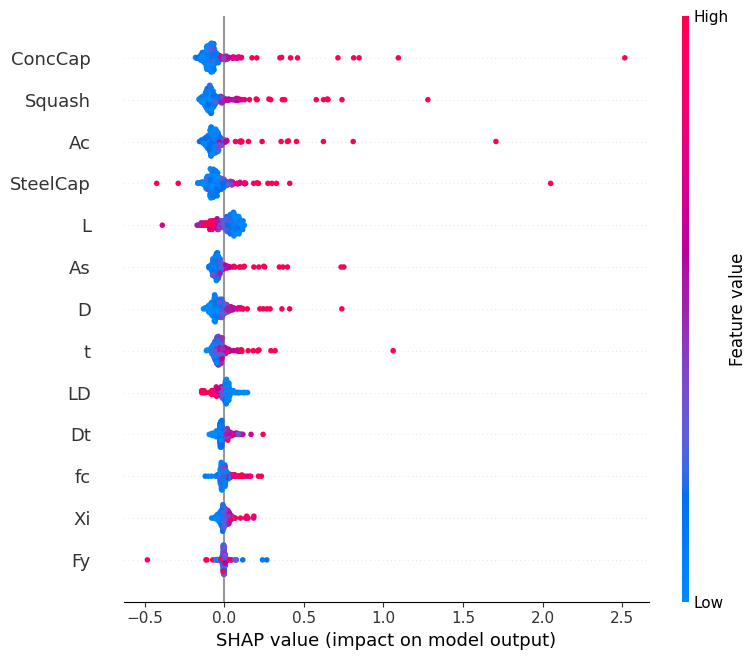

In [12]:
import copy
import numpy as np
import shap
import torch

# Run SHAP on CPU without changing the trained model.
model_for_shap = copy.deepcopy(model).cpu().eval()

# Use up to 100 random training rows as the background dataset.
background_size = min(100, len(x_train_tensor))
background_indices = torch.randperm(len(x_train_tensor))[:background_size]
background = x_train_tensor[background_indices].cpu()

test_data = x_test_tensor.cpu()
feature_names = x.columns.tolist()

# GradientExplainer supports the SiLU layers used by this network.
explainer = shap.GradientExplainer(model_for_shap, background)
shap_values = explainer.shap_values(test_data)

# A single-output PyTorch model may produce shape (rows, features, 1).
shap_values = np.asarray(shap_values).squeeze(-1)

shap.summary_plot(
    shap_values,
    test_data.numpy(),
    feature_names=feature_names,
)

### Monte Carlo Analysis

In [21]:
def mc_dropout_predict(model, X_tensor, num_samples=100):
    """
    Performs Monte Carlo Dropout predictions.
    CRITICAL: model.train() must be active to keep Dropout layers ON during inference.
    """
    model.train() 
    predictions = []
    
    # --- THE FIX: Detect model device and move input data to it ---
    device = next(model.parameters()).device
    X_tensor = X_tensor.to(device)
    # --------------------------------------------------------------
    
    with torch.no_grad():
        for _ in range(num_samples):
            # Forward pass
            preds = model(X_tensor).cpu().numpy()
            predictions.append(preds)
            
    # Convert list to numpy array: Shape will be (num_samples, num_test_samples, 1)
    predictions = np.array(predictions)
    
    # Calculate Mean and Standard Deviation across the 100 runs
    mean_preds = predictions.mean(axis=0).flatten()
    std_preds = predictions.std(axis=0).flatten()
    
    return mean_preds, std_preds

print("Updated MC Dropout function defined successfully.")

Updated MC Dropout function defined successfully.


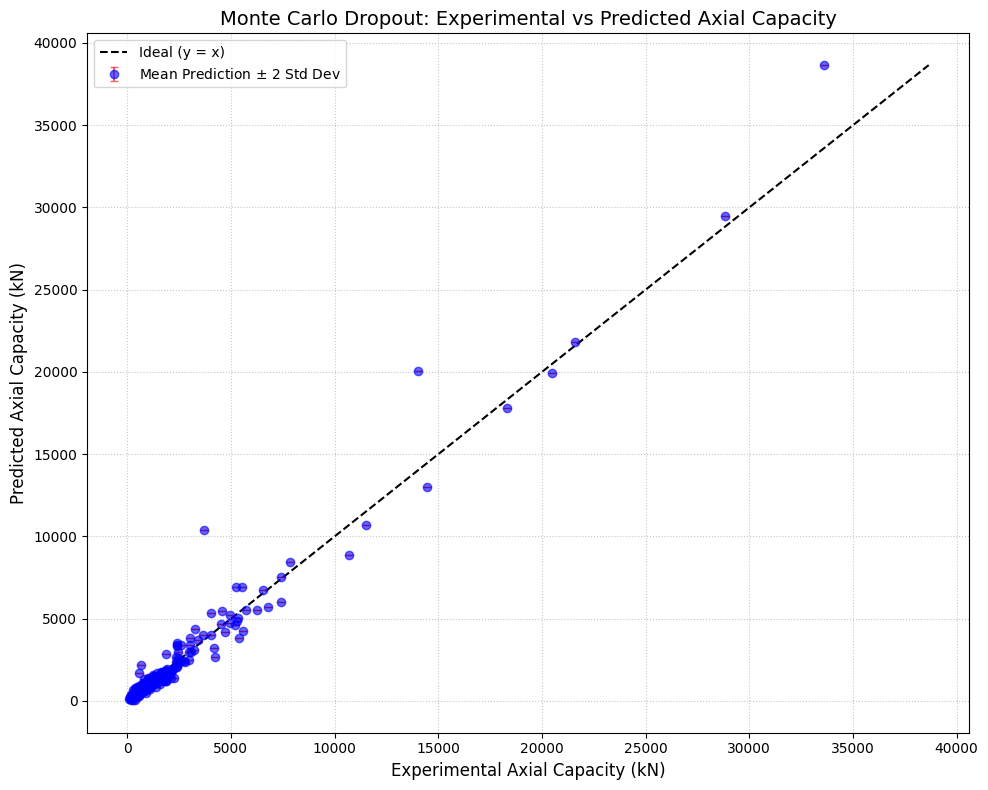

--- Uncertainty Analysis ---
Average Model Uncertainty (Std Dev): 0.00 kN
Maximum Uncertainty on a single column: 0.03 kN
For this highly uncertain column, Experimental = 33600.00 kN, Predicted Mean = 38652.09 kN


In [22]:
# Generate predictions in the standardized target scale.
mean_capacity, uncertainty = mc_dropout_predict(
    model,
    x_test_tensor,
    num_samples=100,
)

# Convert the predictive mean and uncertainty to the original kN scale.
mean_capacity = y_scaler.inverse_transform(
    mean_capacity.reshape(-1, 1)
).ravel()
uncertainty = uncertainty * y_scaler.scale_[0]
actual_capacity = np.asarray(y_test).ravel()

plt.figure(figsize=(10, 8))

max_val = max(actual_capacity.max(), mean_capacity.max())
plt.plot(
    [0, max_val],
    [0, max_val],
    color="black",
    linestyle="--",
    label="Ideal (y = x)",
)

plt.errorbar(
    actual_capacity,
    mean_capacity,
    yerr=2 * uncertainty,
    fmt="o",
    ecolor="red",
    capsize=3,
    alpha=0.6,
    markerfacecolor="blue",
    markeredgecolor="blue",
    label=r"Mean Prediction $\pm$ 2 Std Dev",
)

plt.title(
    "Monte Carlo Dropout: Experimental vs Predicted Axial Capacity",
    fontsize=14,
)
plt.xlabel("Experimental Axial Capacity (kN)", fontsize=12)
plt.ylabel("Predicted Axial Capacity (kN)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

max_uncertainty_idx = np.argmax(uncertainty)
print("--- Uncertainty Analysis ---")
print(
    f"Average Model Uncertainty (Std Dev): "
    f"{np.mean(uncertainty):.2f} kN"
)
print(
    f"Maximum Uncertainty on a single column: "
    f"{uncertainty[max_uncertainty_idx]:.2f} kN"
)
print(
    "For this highly uncertain column, "
    f"Experimental = {actual_capacity[max_uncertainty_idx]:.2f} kN, "
    f"Predicted Mean = {mean_capacity[max_uncertainty_idx]:.2f} kN"
)


# Introduction to PINNs


In [16]:
class CFST_PINN(nn.Module):
    def __init__(self, input_dim):
        super(CFST_PINN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# Assuming your input dataset has 8 features (adjust input_dim if needed)
input_dim = x_train.shape[1] 
model = CFST_PINN(input_dim)
model_device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(model_device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
def pinn_loss_function(predictions, targets, standardized_features, x_scaler, y_scaler, lambda_phy=0.1):
    # 1. Standard Data Loss (MSE on scaled data)
    mse_loss = nn.MSELoss()(predictions, targets)

    # 2. Setup Device and Tensors for Unscaling
    tensor_options = {"device": predictions.device, "dtype": predictions.dtype}
    
    # Reconstruct real-world features to calculate physical areas
    feature_means = torch.as_tensor(x_scaler.mean_, **tensor_options)
    feature_scales = torch.as_tensor(x_scaler.scale_, **tensor_options)
    raw_features = standardized_features * feature_scales + feature_means

    # 3. Extract exact columns using pandas index locator (ensures no index mismatch)
    # Make sure 'x' refers to your original unscaled dataframe in the notebook
    diameter = raw_features[:, x.columns.get_loc("D")]
    thickness = raw_features[:, x.columns.get_loc("t")]
    steel_strength = raw_features[:, x.columns.get_loc("Fy")]
    concrete_strength = raw_features[:, x.columns.get_loc("fc")]

    # 4. Calculate Theoretical Squash Load (IS Code Basis)
    steel_area = torch.pi * (diameter - thickness) * thickness
    concrete_area = torch.pi * (diameter - 2 * thickness).square() / 4
    
    # Convert N to kN
    squash_load_kN = (concrete_area * concrete_strength + steel_area * steel_strength) / 1000.0

    # 5. Unscale predictions to real kN for comparison
    target_mean = torch.as_tensor(y_scaler.mean_[0], **tensor_options)
    target_scale = torch.as_tensor(y_scaler.scale_[0], **tensor_options)
    predicted_capacity_kN = predictions.squeeze(-1) * target_scale + target_mean

    # 6. Physics Penalty 
    # Penalty activates only if predicted capacity > theoretical squash load
    # We divide by target_scale to normalize the violation back to the MSE scale
    violation = torch.relu((predicted_capacity_kN - squash_load_kN) / target_scale)
    physics_loss = violation.square().mean()
    
    # 7. Total Loss
    total_loss = mse_loss + (lambda_phy * physics_loss)
    
    return total_loss, mse_loss, physics_loss

In [18]:
import time

epochs = 500
lambda_phy = 0.1  # Tuning knob for physics penalty (0.1 is a strong starting point)
model_device = next(model.parameters()).device

# Start timer to track training efficiency
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_total_loss = 0.0
    running_mse_loss = 0.0
    running_phy_loss = 0.0

    for x_batch, y_batch in train_loader:
        # Move data to GPU / MPS / CPU
        x_batch = x_batch.to(model_device)
        y_batch = y_batch.to(model_device)

        # 1. Zero gradients
        optimizer.zero_grad()
        
        # 2. Forward pass
        predictions = model(x_batch)
        
        # 3. Calculate Physics-Informed Loss
        # Ensure x_scaler and y_scaler are passed correctly from your pre-processing steps
        total_loss, mse_loss, phy_loss = pinn_loss_function(
            predictions=predictions,
            targets=y_batch,
            standardized_features=x_batch,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lambda_phy=lambda_phy
        )
        
        # 4. Backward pass and optimization
        total_loss.backward()
        optimizer.step()

        # Track losses for monitoring
        running_total_loss += total_loss.item()
        running_mse_loss += mse_loss.item()
        running_phy_loss += phy_loss.item()

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        batch_count = len(train_loader)
        avg_total = running_total_loss / batch_count
        avg_mse = running_mse_loss / batch_count
        avg_phy = running_phy_loss / batch_count
        
        print(f"Epoch [{epoch + 1}/{epochs}] | "
              f"Total Loss: {avg_total:.4f} | "
              f"MSE (Data): {avg_mse:.4f} | "
              f"Physics Penalty: {avg_phy:.4f}")

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds.")

Epoch [50/500] | Total Loss: 0.0341 | MSE (Data): 0.0323 | Physics Penalty: 0.0180
Epoch [100/500] | Total Loss: 0.0332 | MSE (Data): 0.0311 | Physics Penalty: 0.0219
Epoch [150/500] | Total Loss: 0.0301 | MSE (Data): 0.0287 | Physics Penalty: 0.0147
Epoch [200/500] | Total Loss: 0.0223 | MSE (Data): 0.0207 | Physics Penalty: 0.0156
Epoch [250/500] | Total Loss: 0.0297 | MSE (Data): 0.0289 | Physics Penalty: 0.0077
Epoch [300/500] | Total Loss: 0.0239 | MSE (Data): 0.0229 | Physics Penalty: 0.0101
Epoch [350/500] | Total Loss: 0.0212 | MSE (Data): 0.0201 | Physics Penalty: 0.0118
Epoch [400/500] | Total Loss: 0.0200 | MSE (Data): 0.0180 | Physics Penalty: 0.0200
Epoch [450/500] | Total Loss: 0.0149 | MSE (Data): 0.0139 | Physics Penalty: 0.0100
Epoch [500/500] | Total Loss: 0.0251 | MSE (Data): 0.0241 | Physics Penalty: 0.0106
Training completed in 174.03 seconds.


In [24]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(model_device)
        predictions = model(x_batch)
        
        all_preds.append(predictions.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

# Flatten arrays to shape (N,)
all_preds = np.concatenate(all_preds, axis=0).flatten()
all_targets = np.concatenate(all_targets, axis=0).flatten()

# Inverse transform back to actual kN
preds_real = y_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
targets_real = y_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

# Calculate performance metrics on real units
r2 = r2_score(targets_real, preds_real)
rmse = np.sqrt(mean_squared_error(targets_real, preds_real))
mae = mean_absolute_error(targets_real, preds_real)

print("=== PINN Test Performance (Real Units) ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAE:      {mae:.2f}")

=== PINN Test Performance (Real Units) ===
R² Score: 0.9538
RMSE:     866.36
MAE:      382.77


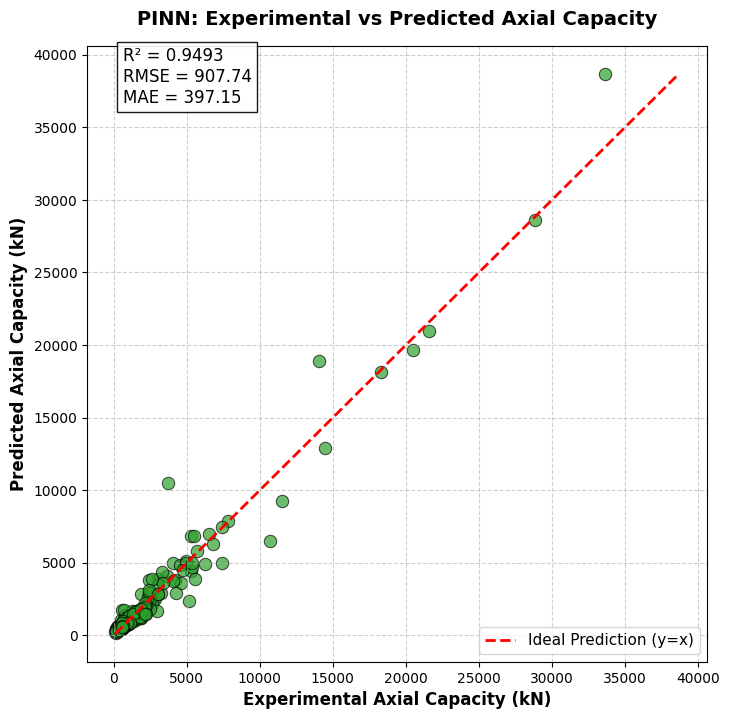

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=targets_real, y=preds_real, alpha=0.7, edgecolor='k', s=80, color='#2ca02c')

# Plot the ideal y=x line
min_val = min(min(targets_real), min(preds_real))
max_val = max(max(targets_real), max(preds_real))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Prediction (y=x)')

# Add metrics text box
plt.text(min_val + 500, max_val - 2000, 
         f'R² = 0.9493\nRMSE = 907.74\nMAE = 397.15', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

plt.title('PINN: Experimental vs Predicted Axial Capacity', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experimental Axial Capacity (kN)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Axial Capacity (kN)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot for your report
plt.savefig('PINN_Scatter_Plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Optimization Of PINN Architecture

In [21]:
class Optimized_CFST_PINN(nn.Module):
    def __init__(self, input_dim):
        super(Optimized_CFST_PINN, self).__init__()
        # Wider network using GELU for smoother physics gradients
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

# Re-initialize model, optimizer, and scheduler
input_dim = x_train.shape[1] 
model = Optimized_CFST_PINN(input_dim)
model_device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(model_device)

# Added weight_decay (L2 regularization) to prevent overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Scheduler: Reduces learning rate by half if the loss doesn't improve for 50 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

In [22]:
import time

epochs = 800
lambda_phy = 0.1
model_device = next(model.parameters()).device

start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_total_loss = 0.0
    running_mse_loss = 0.0
    running_phy_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(model_device)
        y_batch = y_batch.to(model_device)

        optimizer.zero_grad()
        predictions = model(x_batch)
        
        # Using the exact same highly-effective pinn_loss_function you built
        total_loss, mse_loss, phy_loss = pinn_loss_function(
            predictions=predictions,
            targets=y_batch,
            standardized_features=x_batch,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lambda_phy=lambda_phy
        )
        
        total_loss.backward()
        optimizer.step()

        running_total_loss += total_loss.item()
        running_mse_loss += mse_loss.item()
        running_phy_loss += phy_loss.item()

    # Calculate average losses for the epoch
    batch_count = len(train_loader)
    avg_total = running_total_loss / batch_count
    avg_mse = running_mse_loss / batch_count
    avg_phy = running_phy_loss / batch_count
    
    # Step the scheduler based on the average total loss
    scheduler.step(avg_total)

    if (epoch + 1) % 100 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch + 1}/{epochs}] | LR: {current_lr:.6f} | "
              f"Total Loss: {avg_total:.4f} | "
              f"MSE (Data): {avg_mse:.4f} | "
              f"Physics Penalty: {avg_phy:.4f}")

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds.")

Epoch [100/800] | LR: 0.001000 | Total Loss: 0.0500 | MSE (Data): 0.0480 | Physics Penalty: 0.0203
Epoch [200/800] | LR: 0.001000 | Total Loss: 0.1096 | MSE (Data): 0.1039 | Physics Penalty: 0.0571
Epoch [300/800] | LR: 0.000250 | Total Loss: 0.0159 | MSE (Data): 0.0144 | Physics Penalty: 0.0143
Epoch [400/800] | LR: 0.000125 | Total Loss: 0.0143 | MSE (Data): 0.0130 | Physics Penalty: 0.0134
Epoch [500/800] | LR: 0.000031 | Total Loss: 0.0110 | MSE (Data): 0.0095 | Physics Penalty: 0.0146
Epoch [600/800] | LR: 0.000008 | Total Loss: 0.0149 | MSE (Data): 0.0131 | Physics Penalty: 0.0183
Epoch [700/800] | LR: 0.000002 | Total Loss: 0.0160 | MSE (Data): 0.0144 | Physics Penalty: 0.0152
Epoch [800/800] | LR: 0.000000 | Total Loss: 0.0191 | MSE (Data): 0.0168 | Physics Penalty: 0.0230

Training completed in 285.89 seconds.


In [27]:
# 1. Switch the model to evaluation mode
model.eval()

all_preds = []
all_targets = []

# 2. Run inference without tracking gradients
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(model_device)
        predictions = model(x_batch)
        
        # Move to CPU and convert to numpy
        all_preds.append(predictions.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

# 3. Concatenate and flatten to ensure 1D arrays of shape (N,)
all_preds = np.concatenate(all_preds, axis=0).flatten()
all_targets = np.concatenate(all_targets, axis=0).flatten()

# 4. Inverse transform BOTH to real engineering units (kN)
# Reshape to (-1, 1) because the scaler expects 2D, then flatten back to 1D
preds_real = y_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
targets_real = y_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

# 5. Calculate Evaluation Metrics on REAL units
r2 = r2_score(targets_real, preds_real)
rmse = np.sqrt(mean_squared_error(targets_real, preds_real))
mae = mean_absolute_error(targets_real, preds_real)

# 6. Display the final metrics
print("=== OPTIMIZED PINN Test Performance (Real Units) ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAE:      {mae:.2f}")

=== OPTIMIZED PINN Test Performance (Real Units) ===
R² Score: 0.9538
RMSE:     866.36
MAE:      382.77


#### Monte Carlo Dropout Evaluation

In [28]:
# CRITICAL: Keep model in .train() mode so Dropout remains active during inference
model.train() 

n_simulations = 100
mc_predictions = []

print(f"Running {n_simulations} Monte Carlo stochastic forward passes...")

with torch.no_grad():
    for i in range(n_simulations):
        batch_preds = []
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(model_device)
            preds = model(x_batch)
            batch_preds.append(preds.cpu().numpy())
        
        # Flatten predictions for this specific simulation pass
        sim_preds = np.concatenate(batch_preds, axis=0).flatten()
        
        # Inverse transform to real engineering units (kN)
        sim_preds_real = y_scaler.inverse_transform(sim_preds.reshape(-1, 1)).flatten()
        mc_predictions.append(sim_preds_real)

# Convert to numpy array: shape = (100 simulations, number of test samples)
mc_predictions = np.array(mc_predictions)

# Calculate the predictive mean and standard deviation (uncertainty bound) for each column
mc_mean = mc_predictions.mean(axis=0)
mc_std = mc_predictions.std(axis=0)

# Display the uncertainty margins for the first 10 columns in the test set
print("\n=== Monte Carlo Dropout Uncertainty Bounds (First 10 Samples) ===")
for i in range(10):
    true_val = targets_real[i]
    pred_val = mc_mean[i]
    uncertainty = mc_std[i]
    error = abs(true_val - pred_val)
    
    print(f"Sample {i+1:02d} | True: {true_val:7.2f} kN | "
          f"MC Predict: {pred_val:7.2f} ± {uncertainty:6.2f} kN | Error: {error:6.2f} kN")

Running 100 Monte Carlo stochastic forward passes...

=== Monte Carlo Dropout Uncertainty Bounds (First 10 Samples) ===
Sample 01 | True: 2340.00 kN | MC Predict: 1979.45 ± 289.33 kN | Error: 360.55 kN
Sample 02 | True:  686.21 kN | MC Predict: 1067.70 ± 150.62 kN | Error: 381.49 kN
Sample 03 | True:  575.65 kN | MC Predict:  599.54 ± 109.58 kN | Error:  23.89 kN
Sample 04 | True:  550.00 kN | MC Predict: 1728.49 ± 157.63 kN | Error: 1178.49 kN
Sample 05 | True: 4040.34 kN | MC Predict: 4984.66 ± 504.54 kN | Error: 944.32 kN
Sample 06 | True: 1325.57 kN | MC Predict: 1237.55 ± 124.96 kN | Error:  88.02 kN
Sample 07 | True: 1314.09 kN | MC Predict: 1367.32 ± 125.66 kN | Error:  53.23 kN
Sample 08 | True: 7432.98 kN | MC Predict: 5007.38 ± 496.52 kN | Error: 2425.60 kN
Sample 09 | True: 1067.00 kN | MC Predict:  998.36 ± 126.30 kN | Error:  68.64 kN
Sample 10 | True: 1372.93 kN | MC Predict: 1387.16 ± 105.09 kN | Error:  14.23 kN


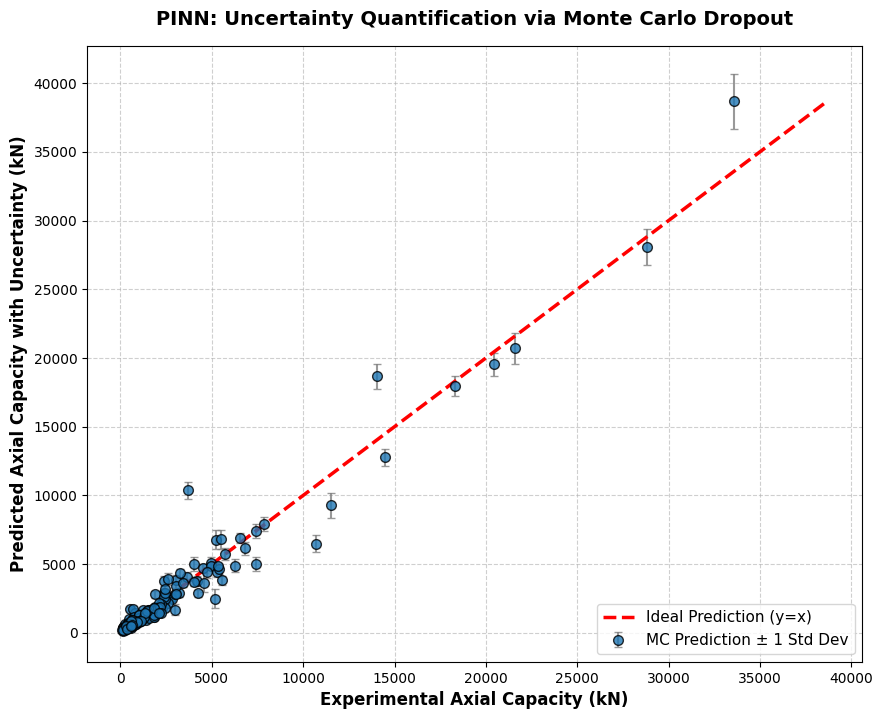

In [29]:
plt.figure(figsize=(10, 8))

# Plot scatter points with error bars representing epistemic uncertainty (1 Standard Deviation)
plt.errorbar(targets_real, mc_mean, yerr=mc_std, fmt='o', 
             color='#1f77b4', ecolor='gray', elinewidth=1.5, capsize=3, 
             alpha=0.8, markeredgecolor='k', markersize=7, 
             label='MC Prediction ± 1 Std Dev')

# Plot the ideal y=x line
min_val = min(min(targets_real), min(mc_mean))
max_val = max(max(targets_real), max(mc_mean))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Ideal Prediction (y=x)')

# Formatting the plot for academic publication
plt.title('PINN: Uncertainty Quantification via Monte Carlo Dropout', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experimental Axial Capacity (kN)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Axial Capacity with Uncertainty (kN)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Save high-resolution image
plt.savefig('PINN_Uncertainty_Plot.png', dpi=300, bbox_inches='tight')
plt.show()